In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import math
import gc
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error,
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [28]:
df = pd.read_csv("south_Afric_Rainfall_43y.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82368 entries, 0 to 82367
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       82368 non-null  object 
 1   adm_level  82368 non-null  int64  
 2   adm_id     82368 non-null  int64  
 3   PCODE      82368 non-null  int64  
 4   n_pixels   82368 non-null  float64
 5   rfh        82368 non-null  float64
 6   rfh_avg    82368 non-null  float64
 7   r1h        82368 non-null  float64
 8   r1h_avg    82368 non-null  float64
 9   r3h        82368 non-null  float64
 10  r3h_avg    82368 non-null  float64
 11  rfq        82368 non-null  float64
 12  r1q        82368 non-null  float64
 13  r3q        82368 non-null  float64
 14  version    82368 non-null  object 
 15  month      82368 non-null  int64  
 16  dekad      82368 non-null  int64  
dtypes: float64(10), int64(5), object(2)
memory usage: 10.7+ MB


In [29]:
len(df["PCODE"].unique())

52

In [30]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

df = df.drop(['date', 'adm_level', 'adm_id', 'version', 'n_pixels'], axis=1 )
df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
df.columns

Index(['PCODE', 'rfh', 'rfh_avg', 'r1h', 'r1h_avg', 'r3h', 'r3h_avg', 'rfq',
       'r1q', 'r3q', 'month', 'dekad', 'year'],
      dtype='object')

In [31]:
DROP_COLS = [
    'rfq','r1q','r3q','rfh_avg','r1h_avg','r3h_avg',
    'n_pixels','version','Unnamed: 0','adm_id','adm_level',
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df = df.sort_values(['PCODE','year','month','dekad']).reset_index(drop=True)
print(f'Raw shape: {df.shape}')
df.head(10)

Raw shape: (82368, 7)


,PCODE,rfh,r1h,r3h,month,dekad,year
0,0,1.486920,6.076793,27.927425,1,1,1982
1,0,9.145991,12.382278,31.688606,1,11,1982
2,0,2.005063,12.637975,29.567087,1,21,1982
3,0,1.492827,12.643882,29.481010,2,1,1982
4,0,1.535865,5.033755,28.220253,2,11,1982
5,0,1.457384,4.486076,23.765402,2,21,1982
6,0,7.253165,10.246414,28.967089,3,1,1982
7,0,2.178059,10.888607,28.304642,3,11,1982
8,0,11.572996,21.004220,38.128270,3,21,1982
9,0,18.546835,32.297890,55.188187,4,1,1982


In [32]:
# Lag features
for lag in [1, 2, 3, 6, 12]:
    df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)
df = df.dropna().reset_index(drop=True)

# Encode PCODE
df['PCODE'] = df['PCODE'].astype('category').cat.codes
NUM_PCODES  = df['PCODE'].nunique()

# Cyclic time features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dekad_sin'] = np.sin(2 * np.pi * df['dekad'] / 3)
df['dekad_cos'] = np.cos(2 * np.pi * df['dekad'] / 3)

print(f'df: {df.shape}, PCODEs: {NUM_PCODES}')
df.head()

df: (81744, 16), PCODEs: 52


,PCODE,rfh,r1h,r3h,month,dekad,year,rfh_lag_1,rfh_lag_2,rfh_lag_3,rfh_lag_6,rfh_lag_12,month_sin,month_cos,dekad_sin,dekad_cos
0,0,9.780591,22.472572,65.01688,5,1,1982,6.028692,6.663291,18.546835,7.253165,1.486920,5.000000e-01,-0.866025,8.660254e-01,-0.5
1,0,10.942616,26.751900,74.42363,5,11,1982,9.780591,6.028692,6.663291,2.178059,9.145991,5.000000e-01,-0.866025,-8.660254e-01,-0.5
2,0,6.887764,27.610971,79.85401,5,21,1982,10.942616,9.780591,6.028692,11.572996,2.005063,5.000000e-01,-0.866025,-1.714506e-15,1.0
3,0,14.955275,32.785652,87.55612,6,1,1982,6.887764,10.942616,9.780591,18.546835,1.492827,1.224647e-16,-1.000000,8.660254e-01,-0.5
4,0,9.811814,31.654854,95.18987,6,11,1982,14.955275,6.887764,10.942616,6.663291,1.535865,1.224647e-16,-1.000000,-8.660254e-01,-0.5


In [33]:
train_df = df[df['year'] <= 2015]
val_df = df[(df['year'] > 2015) & (df['year'] <= 2020)]
test_df = df[df['year'] > 2020]

print("train:",(train_df.shape))
print("val:",(val_df.shape))
print("test:",(test_df.shape))

train: (63024, 16)
val: (9360, 16)
test: (9360, 16)


In [34]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

In [35]:
transform_cols = [
    'rfh', 'r1h', 'r3h',
    'rfh_lag_1', 'rfh_lag_2','rfh_lag_3', 'rfh_lag_6','rfh_lag_12'
]
# Apply Yeo–Johnson
pt = PowerTransformer(method='yeo-johnson')

train_df[transform_cols] = pt.fit_transform(train_df[transform_cols])
val_df[transform_cols] = pt.transform(val_df[transform_cols])
test_df[transform_cols] = pt.transform(test_df[transform_cols])

# Apply RobustScaler
scaler = RobustScaler()

train_df[transform_cols] = scaler.fit_transform(train_df[transform_cols])
val_df[transform_cols] = scaler.transform(val_df[transform_cols])
test_df[transform_cols] = scaler.transform(test_df[transform_cols])

In [36]:
FEATURES = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin','month_cos','dekad_sin','dekad_cos',
    'month','dekad',
]
TARGET    = 'rfh'
SEQ_LEN   = 36 
NUM_FEATS = len(FEATURES)
print(f'Features: {NUM_FEATS} , Sequence length: {SEQ_LEN}')

Features: 14 , Sequence length: 36


In [37]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_val = val_df[FEATURES].values
y_val = val_df[TARGET].values

X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

X_train = X_train.astype('float32')
y_train = y_train.astype('float32')
X_val = X_val.astype('float32')
y_val = y_val.astype('float32')
X_test = X_test.astype('float32')
y_test = y_test.astype('float32')

X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_val = torch.tensor(X_val)
y_val = torch.tensor(y_val)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

In [38]:
def create_sequences_per_pcode(df, features, target, seq_len=36):
    X_list, y_list, pcode_list = [], [], []
    
    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])
        
        X = group[features].values
        y = group[target].values
        
        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)
    
    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [39]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, FEATURES , TARGET)
X_val, y_val, p_val = create_sequences_per_pcode(val_df, FEATURES , TARGET)
X_test, y_test, p_test = create_sequences_per_pcode(test_df, FEATURES, TARGET)

In [40]:
X_train.shape # (batch_size, sequence_length, num_features)

torch.Size([61152, 36, 14])

In [41]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=False)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False)

In [42]:
# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]

In [43]:
class TransformerModel(nn.Module):
    def __init__(self, input_dim, num_pcodes, embed_dim, d_model, n_heads, num_layers, dropout):
        super().__init__()
        
        self.embedding = nn.Embedding(num_pcodes, embed_dim)
        
        self.input_proj = nn.Linear(input_dim + embed_dim, d_model)

        self.pos_encoder = PositionalEncoding(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.norm = nn.LayerNorm(d_model)  # Layer Normalization

        # Regression Head
        self.fc = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x, pcode):     # Forward Pass 
        emb = self.embedding(pcode)   # PCODE Embedding , shape =  (batch, embed_dim)
        
        emb = emb.unsqueeze(1).repeat(1, x.size(1), 1)  # shape = (batch, seq_len, embed_dim)
        
        x = torch.cat([x, emb], dim=2)
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.transformer(x)
        x = self.norm(x)
        x = x[:, -1, :]
        x = self.fc(x)            # Regression Output

        return x.squeeze(-1)

In [44]:
def objective(trial):
    try:
        torch.cuda.empty_cache()
        gc.collect()

        d_model = trial.suggest_categorical("d_model", [64,128, 256])
        n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
        # d_model must be divisible by n_heads
        if d_model % n_heads != 0:
            raise optuna.TrialPruned()
        num_layers = trial.suggest_int("num_layers", low=1,high=4)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
        embed_dim = trial.suggest_categorical("embed_dim", [4, 8, 16])
        weight_decay = trial.suggest_float("weight_decay",1e-6, 1e-3, log=True)

        model = TransformerModel(
            input_dim=X_train.shape[2],
            num_pcodes=df['PCODE'].nunique(),
            embed_dim=embed_dim,
            d_model=d_model,
            n_heads=n_heads,
            num_layers=num_layers,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2
        )
        loss_fn = nn.MSELoss()

        #  TRAIN
        for epoch in range(10):
            model.train()
            train_loss = 0.0

            for xb, yb, pb in train_loader:
                xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

                optimizer.zero_grad()
                pred = model(xb, pb)

                loss = loss_fn(pred.view(-1), yb.view(-1))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # Gradient clipping
                optimizer.step()

                train_loss += loss.item()

            train_loss /= len(train_loader)


            # Validation 
            model.eval()
            val_loss = 0.0

            with torch.no_grad():
                for xb, yb, pb in val_loader:
                    xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

                    pred = model(xb, pb)
                    loss = loss_fn(pred.view(-1), yb.view(-1))
                    val_loss += loss.item()

            val_loss /= len(val_loader)
            scheduler.step(val_loss)
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()
            print(
                f"Trial {trial.number} | "
                f"Epoch {epoch+1} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f}"
            )
        return val_loss

    except optuna.TrialPruned:
        raise

    except Exception as e:

        print("Trial failed:", e)

        return float("inf")

In [45]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20) 

Trial 0 | Epoch 1 | Train Loss: 0.202330 | Val Loss: 0.176648
Trial 0 | Epoch 2 | Train Loss: 0.153249 | Val Loss: 0.134133
Trial 0 | Epoch 3 | Train Loss: 0.137646 | Val Loss: 0.126945
Trial 0 | Epoch 4 | Train Loss: 0.131292 | Val Loss: 0.123933
Trial 0 | Epoch 5 | Train Loss: 0.127004 | Val Loss: 0.122340
Trial 0 | Epoch 6 | Train Loss: 0.125836 | Val Loss: 0.120928
Trial 0 | Epoch 7 | Train Loss: 0.123421 | Val Loss: 0.119846
Trial 0 | Epoch 8 | Train Loss: 0.123033 | Val Loss: 0.118284
Trial 0 | Epoch 9 | Train Loss: 0.123237 | Val Loss: 0.123487
Trial 0 | Epoch 10 | Train Loss: 0.123675 | Val Loss: 0.122042
Trial 1 | Epoch 1 | Train Loss: 0.255356 | Val Loss: 0.156616
Trial 1 | Epoch 2 | Train Loss: 0.155486 | Val Loss: 0.133823
Trial 1 | Epoch 3 | Train Loss: 0.139265 | Val Loss: 0.141088
Trial 1 | Epoch 4 | Train Loss: 0.132064 | Val Loss: 0.133713
Trial 1 | Epoch 5 | Train Loss: 0.127804 | Val Loss: 0.128673
Trial 1 | Epoch 6 | Train Loss: 0.124631 | Val Loss: 0.126175
Trial 1

In [46]:
print("Best Trial Loss:", study.best_trial.value)

best = study.best_params

print("\nBest Params:")
for k, v in best.items():
    print(f"{k}: {v}")

Best Trial Loss: 0.11061604718367259

Best Params:
d_model: 64
n_heads: 2
num_layers: 3
dropout: 0.22027227653243042
lr: 7.50166522759359e-05
embed_dim: 4
weight_decay: 0.0002341355059950679


In [47]:
model = TransformerModel(
    input_dim=X_train.shape[2],
    num_pcodes=df['PCODE'].nunique(),
    embed_dim=best['embed_dim'],
    d_model=best['d_model'],
    n_heads=best['n_heads'],
    num_layers=best['num_layers'],
    dropout=best['dropout']
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best['lr'])
loss_fn = nn.MSELoss()

In [48]:
for epoch in range(50):
    model.train()
    total_loss = 0

    for xb, yb, pb in train_loader:
        xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

        optimizer.zero_grad()
        pred = model(xb, pb)

        loss = loss_fn(pred.view(-1), yb.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

Epoch 1, Loss: 0.2712
Epoch 2, Loss: 0.1511
Epoch 3, Loss: 0.1355
Epoch 4, Loss: 0.1278
Epoch 5, Loss: 0.1223
Epoch 6, Loss: 0.1203
Epoch 7, Loss: 0.1184
Epoch 8, Loss: 0.1170
Epoch 9, Loss: 0.1157
Epoch 10, Loss: 0.1157
Epoch 11, Loss: 0.1147
Epoch 12, Loss: 0.1146
Epoch 13, Loss: 0.1143
Epoch 14, Loss: 0.1143
Epoch 15, Loss: 0.1142
Epoch 16, Loss: 0.1134
Epoch 17, Loss: 0.1131
Epoch 18, Loss: 0.1120
Epoch 19, Loss: 0.1121
Epoch 20, Loss: 0.1111
Epoch 21, Loss: 0.1110
Epoch 22, Loss: 0.1105
Epoch 23, Loss: 0.1110
Epoch 24, Loss: 0.1105
Epoch 25, Loss: 0.1098
Epoch 26, Loss: 0.1095
Epoch 27, Loss: 0.1095
Epoch 28, Loss: 0.1089
Epoch 29, Loss: 0.1089
Epoch 30, Loss: 0.1087
Epoch 31, Loss: 0.1083
Epoch 32, Loss: 0.1082
Epoch 33, Loss: 0.1077
Epoch 34, Loss: 0.1078
Epoch 35, Loss: 0.1072
Epoch 36, Loss: 0.1071
Epoch 37, Loss: 0.1074
Epoch 38, Loss: 0.1068
Epoch 39, Loss: 0.1071
Epoch 40, Loss: 0.1069
Epoch 41, Loss: 0.1060
Epoch 42, Loss: 0.1064
Epoch 43, Loss: 0.1064
Epoch 44, Loss: 0.10

In [49]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb, pb in val_loader:
        xb, yb, pb = xb.to(device), yb.to(device), pb.to(device)

        pred = model(xb, pb)

        all_preds.extend(pred.view(-1).cpu().numpy())
        all_targets.extend(yb.view(-1).cpu().numpy())

In [50]:
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae  = mean_absolute_error(all_targets, all_preds)
r2   = r2_score(all_targets, all_preds)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.33753005
MAE : 0.2536715
R2  : 0.6958752462329867


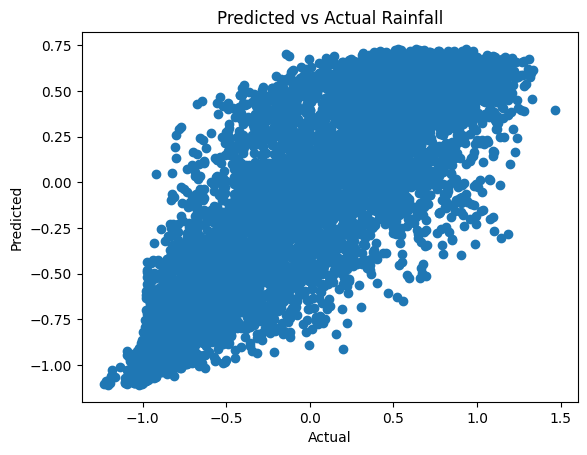

In [51]:
plt.figure()
plt.scatter(all_targets, all_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()

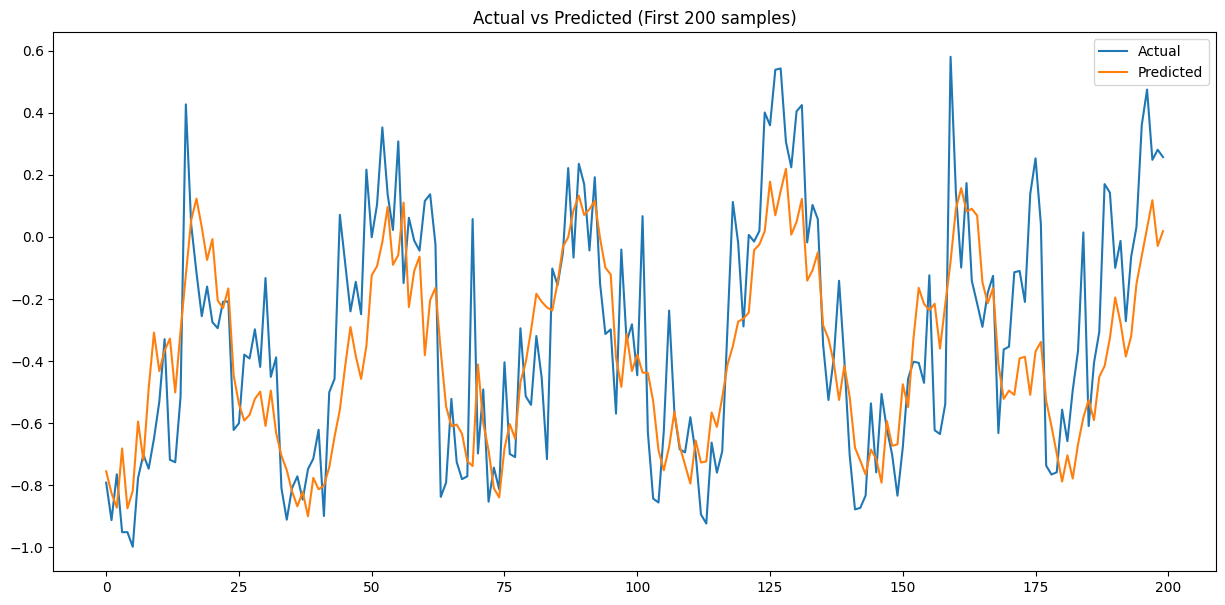

In [52]:
plt.figure(figsize=(15, 7))
plt.plot(all_targets[:200], label="Actual")
plt.plot(all_preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 200 samples)")
plt.show()